# 03 — ON 상태 안정성 분석

두 데이터셋(memeffect_sweep, memeffect_sweep_aug30)에서 `already_on` 행만 추출해 Chip별·Run별·광조건별 i_on 분포를 분석한다.

## 섹션 1 — 데이터 합치기

두 CSV를 합치고 `already_on` 상태만 필터링한 뒤, 파일명에서 chip_id와 run_number를 파싱한다.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats as sp_stats
from scipy.stats import mannwhitneyu

# ── 한글 폰트 설정 (macOS)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

PATH1 = "../data/processed/memeffect_sweep.csv"
PATH2 = "../data/processed/memeffect_sweep_aug30.csv"

df1 = pd.read_csv(PATH1)
df2 = pd.read_csv(PATH2)

# ── already_on 필터
df1 = df1[df1["switching_state"] == "already_on"].copy()
df2 = df2[df2["switching_state"] == "already_on"].copy()

# ── 파일명에서 chip_id 파싱
def parse_chip_id(filename: str) -> str:
    m = re.match(r"(Chip#\d+)", str(filename))
    return m.group(1) if m else "Unknown"

# ── 파일명에서 run_number 파싱
def parse_run_number(filename: str):
    m = re.search(r"Run (\d+)", str(filename))
    return int(m.group(1)) if m else np.nan

for df in (df1, df2):
    df["chip_id"]    = df["filename"].apply(parse_chip_id)
    df["run_number"] = df["filename"].apply(parse_run_number)

# df1 condition 컬럼 유지; df2는 NaN → "Unknown"으로
df2["condition"] = df2["condition"].fillna("Unknown")

combined = pd.concat([df1, df2], ignore_index=True)

print(f"df1 already_on rows : {len(df1)}")
print(f"df2 already_on rows : {len(df2)}")
print(f"combined shape      : {combined.shape}")
print(f"chip_id 분포:\n{combined['chip_id'].value_counts().to_string()}")


df1 already_on rows : 31
df2 already_on rows : 84
combined shape      : (115, 23)
chip_id 분포:
chip_id
Chip#14    81
Chip#1     31
Chip#6      3


## 섹션 2 — Chip별 i_on 분포

각 Chip의 ON 전류 분포를 boxplot(log scale)으로 시각화하고 중앙값·표준편차를 출력한다.

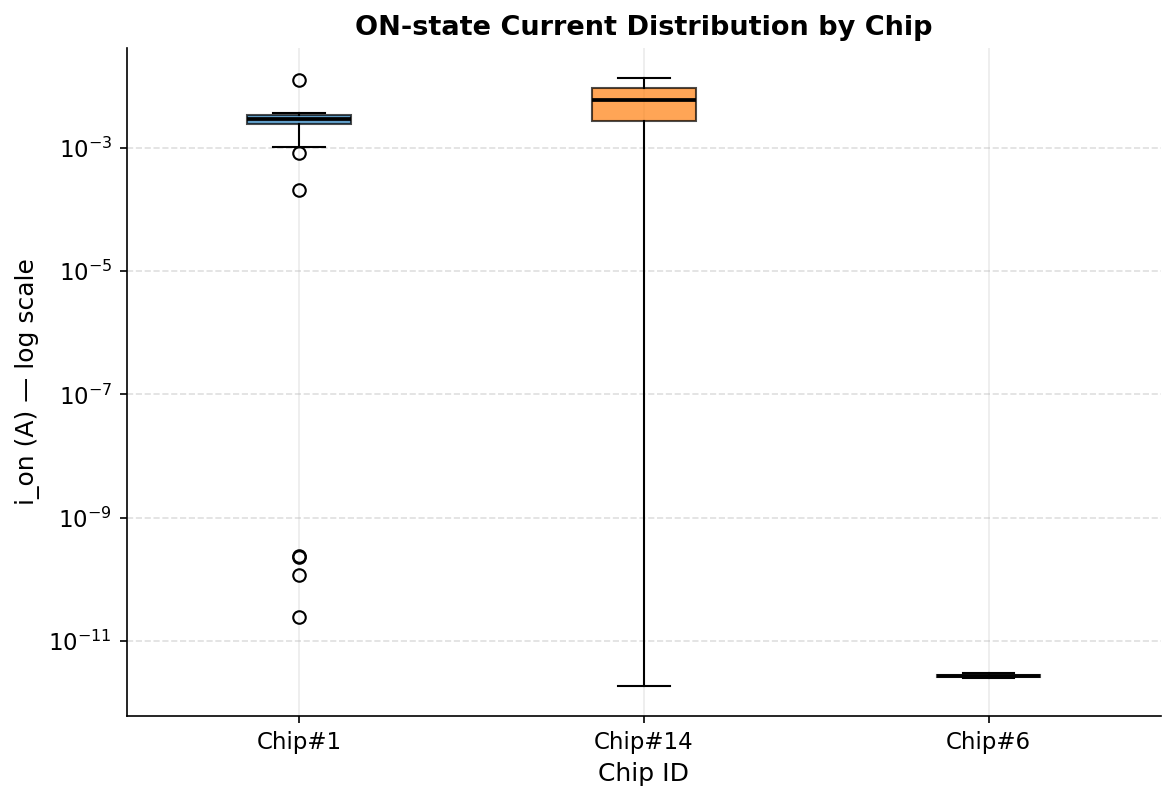


── 통계 요약 ──
         count        median           std           min           max
chip_id                                                               
Chip#1      31  2.936977e-03  2.227575e-03  2.481925e-11  1.272024e-02
Chip#14     81  6.048995e-03  4.220677e-03  1.873136e-12  1.360121e-02
Chip#6       3  2.645016e-12  2.519639e-13  2.486014e-12  2.979636e-12


In [2]:
chips = sorted(combined["chip_id"].unique())
groups = [combined.loc[combined["chip_id"] == c, "i_on_A"].dropna().values for c in chips]

fig, ax = plt.subplots(figsize=(8, 5.5))
bp = ax.boxplot(groups, tick_labels=chips, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=1.8))

colors = plt.cm.tab10.colors
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yscale("log")
ax.set_xlabel("Chip ID", fontsize=12)
ax.set_ylabel("i_on (A) — log scale", fontsize=12)
ax.set_title("ON-state Current Distribution by Chip", fontsize=13)
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.grid(axis="y", which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../results/figures/03_chip_ion_boxplot.png", dpi=150)
plt.show()

print("\n── 통계 요약 ──")
stats = (combined.groupby("chip_id")["i_on_A"]
         .agg(count="count", median="median", std="std", min="min", max="max"))
print(stats.to_string())


## 섹션 3 — Run 번호별 i_on 변화

측정 순서(run_number)에 따른 ON 전류 추이를 Chip별 색상으로 구분하고 추세선을 추가한다.

Chip#1    slope=4.8802e-05  R²=0.000  p=0.993
Chip#14   slope=1.0063e-01  R²=0.478  p=0.000
Chip#6    slope=1.3462e-02  R²=0.113  p=0.781


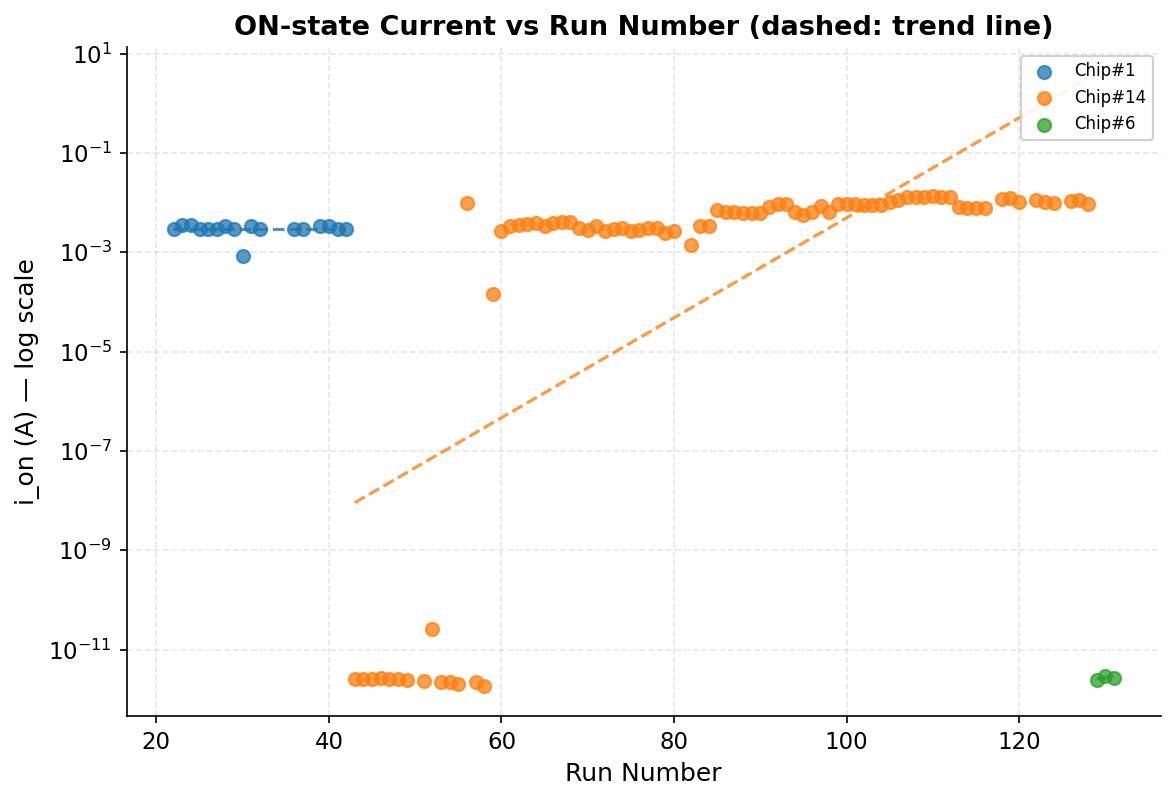

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))

palette = {chip: plt.cm.tab10.colors[i % 10] for i, chip in enumerate(chips)}

for chip in chips:
    sub = combined[combined["chip_id"] == chip].dropna(subset=["run_number", "i_on_A"])
    sub = sub.sort_values("run_number")
    x = sub["run_number"].values.astype(float)
    y = sub["i_on_A"].values

    ax.scatter(x, y, label=chip, color=palette[chip], s=40, alpha=0.75, zorder=3)

    # log10(y) 기준 선형 추세선
    log_y = np.log10(y)
    if len(x) >= 2:
        slope, intercept, r, p, _ = sp_stats.linregress(x, log_y)
        x_fit = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_fit, 10 ** (slope * x_fit + intercept),
                color=palette[chip], linewidth=1.5, linestyle="--", alpha=0.8)
        print(f"{chip:8s}  slope={slope:.4e}  R²={r**2:.3f}  p={p:.3f}")

ax.set_yscale("log")
ax.set_xlabel("Run Number", fontsize=12)
ax.set_ylabel("i_on (A) — log scale", fontsize=12)
ax.set_title("ON-state Current vs Run Number (dashed: trend line)", fontsize=13)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.grid(which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/03_run_ion_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 섹션 4 — 광조건별 i_on 비교

`condition` 컬럼을 파싱해 Dark / Dark-ThenLight / Other 그룹으로 분류하고 Mann-Whitney U 검정으로 유의미한 차이를 확인한다.

Light condition distribution:
light_group
Other             109
Dark-ThenLight      6


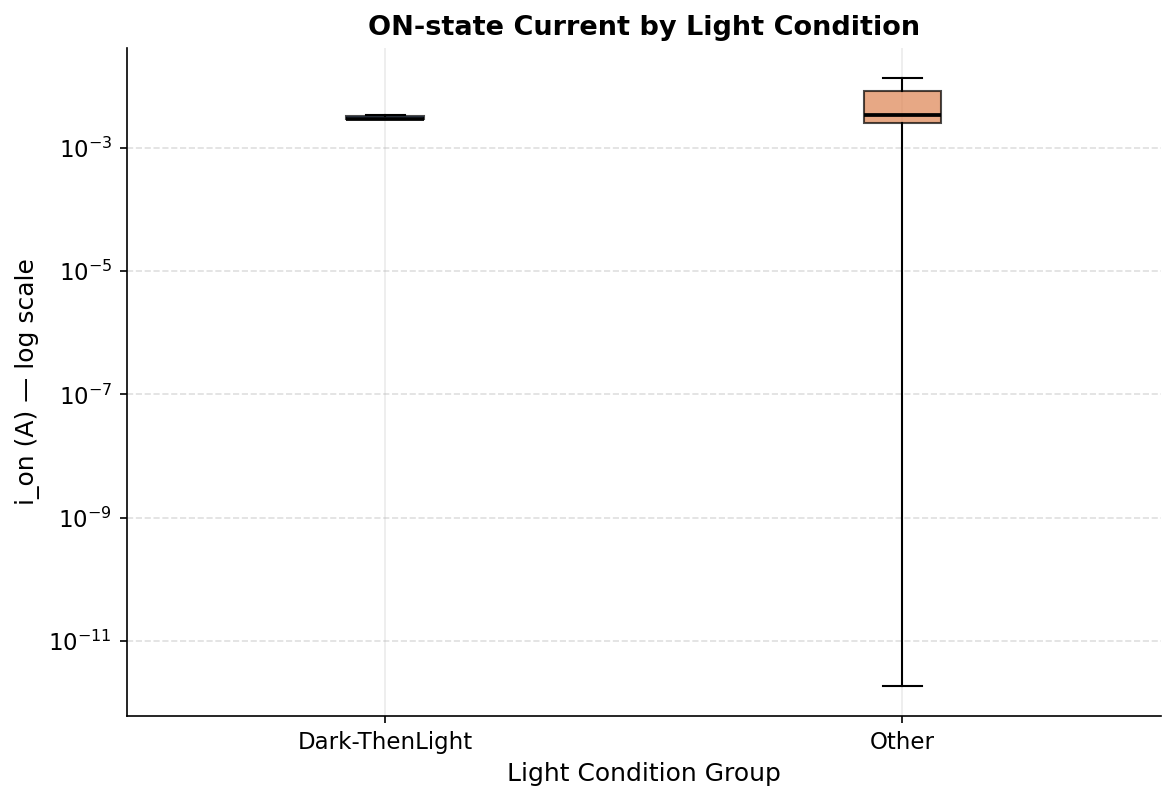


── Mann-Whitney U Test ──
  Dark-ThenLight vs Other                 U=235.0  p=0.2498    not significant


In [4]:
def classify_light(condition: str) -> str:
    c = str(condition)
    if "ThenLight" in c:
        return "Dark-ThenLight"
    elif "Dark" in c:
        return "Dark"
    else:
        return "Other"

combined["light_group"] = combined["condition"].apply(classify_light)
print("Light condition distribution:")
print(combined["light_group"].value_counts().to_string())

groups_lc = sorted(combined["light_group"].unique())
data_lc   = [combined.loc[combined["light_group"] == g, "i_on_A"].dropna().values
             for g in groups_lc]

fig, ax = plt.subplots(figsize=(8, 5.5))
bp = ax.boxplot(data_lc, tick_labels=groups_lc, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.8))

lc_colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], lc_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yscale("log")
ax.set_xlabel("Light Condition Group", fontsize=12)
ax.set_ylabel("i_on (A) — log scale", fontsize=12)
ax.set_title("ON-state Current by Light Condition", fontsize=13)
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.grid(axis="y", which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../results/figures/03_lightcond_ion_boxplot.png", dpi=150)
plt.show()

# ── Mann-Whitney U 검정 (모든 쌍)
print("\n── Mann-Whitney U Test ──")
for i in range(len(groups_lc)):
    for j in range(i + 1, len(groups_lc)):
        a, b = data_lc[i], data_lc[j]
        if len(a) >= 2 and len(b) >= 2:
            stat, pval = mannwhitneyu(a, b, alternative="two-sided")
            sig = "**significant**" if pval < 0.05 else "  not significant"
            print(f"  {groups_lc[i]} vs {groups_lc[j]:20s}  U={stat:.1f}  p={pval:.4f}  {sig}")
        else:
            print(f"  {groups_lc[i]} vs {groups_lc[j]} — insufficient samples (n={len(a)}, {len(b)})")
